# 03 - Exploratory Data Analysis (EDA)

## Objective

Explore campaign performance, customer behavior, financial metrics, and marketing effectiveness through statistical analysis and visualizations to uncover actionable business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("C:/Users/Hp/OneDrive/Desktop/Digital Advertising Campaign Performance Analytics/Data/tech_advertising_campaigns_dataset.csv")

In [3]:
df.head()

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit,Year,Month,Quarter,Weekday
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.23,66329,402,2,896.46,289.67,67.75,70,2.00,E-commerce,High,0.606,2.23,0.498,448.23,0.32,-606.79,2024,March,1,Wednesday
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.48,50094,467,5,1158.16,1728.20,63.73,105,2.74,Finance,Medium,0.932,2.48,1.071,231.63,1.49,570.04,2024,January,1,Friday
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.88,10842,112,6,434.56,2903.26,31.93,149,3.97,Healthcare,Low,1.033,3.88,5.357,72.43,6.68,2468.70,2025,May,2,Thursday
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.29,7820,123,3,1019.67,502.28,65.52,147,2.49,Education,Medium,1.573,8.29,2.439,339.89,0.49,-517.39,2024,July,3,Sunday
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.41,21436,302,0,425.82,0.00,68.95,81,3.04,SaaS,Low,1.409,1.41,0.000,0.00,0.00,-425.82,2025,March,1,Sunday


## Univariate Analysis

### Business Question

What is the distribution of key marketing metrics?

Charts
- Ad Spend
- Revenue
- Profit
- CTR
- ROAS
- Conversion Rate

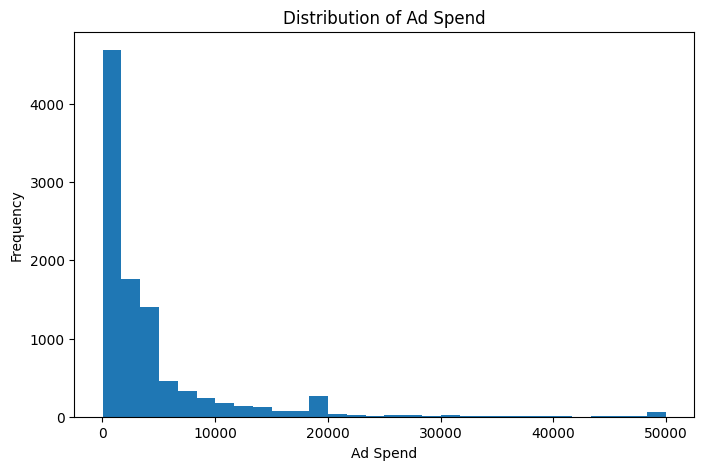

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["ad_spend"], bins=30)
plt.title("Distribution of Ad Spend")
plt.xlabel("Ad Spend")
plt.ylabel("Frequency")
plt.show()

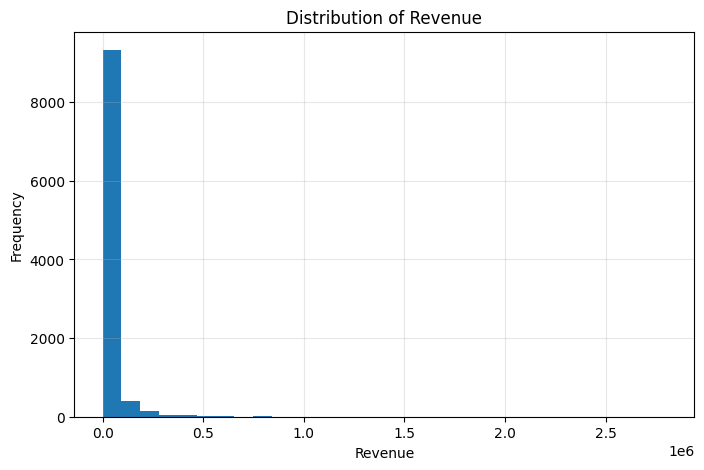

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["revenue"], bins=30)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

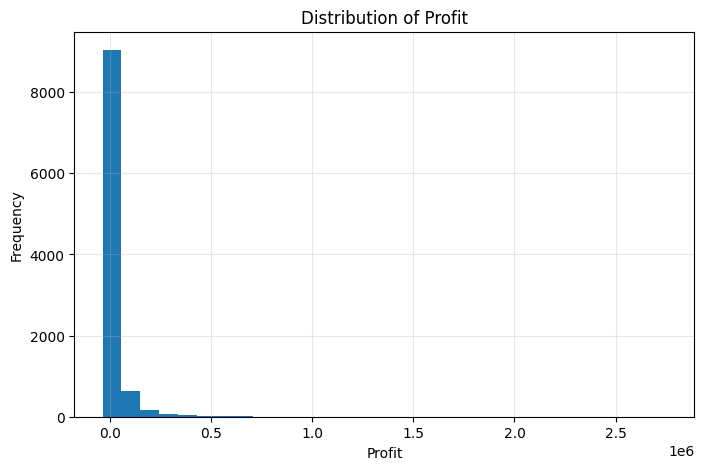

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["profit"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

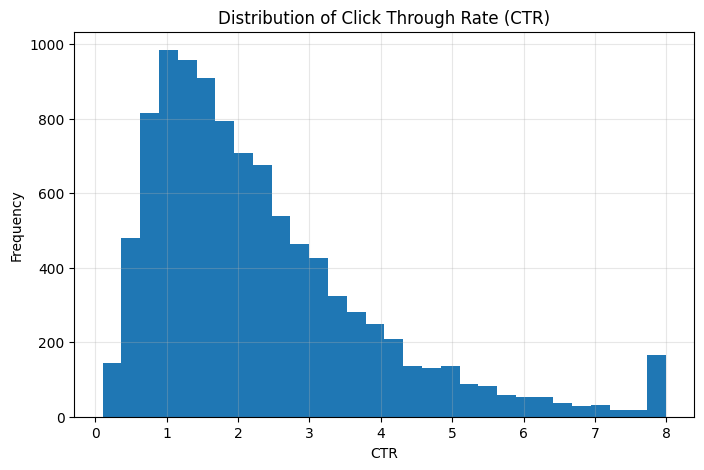

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["CTR"], bins=30)
plt.title("Distribution of Click Through Rate (CTR)")
plt.xlabel("CTR")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

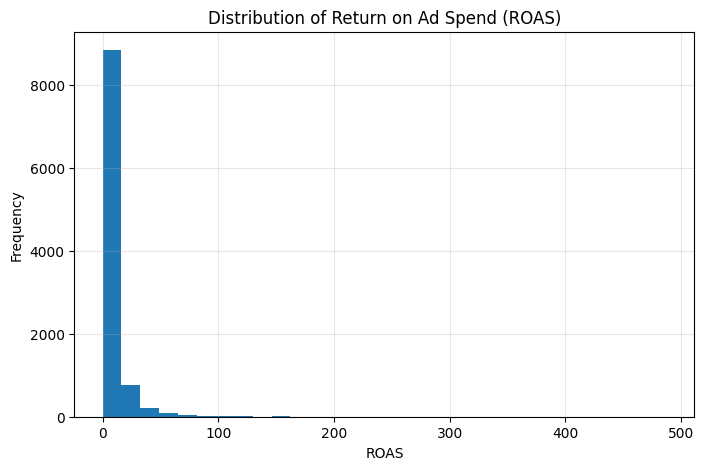

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["ROAS"], bins=30)
plt.title("Distribution of Return on Ad Spend (ROAS)")
plt.xlabel("ROAS")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

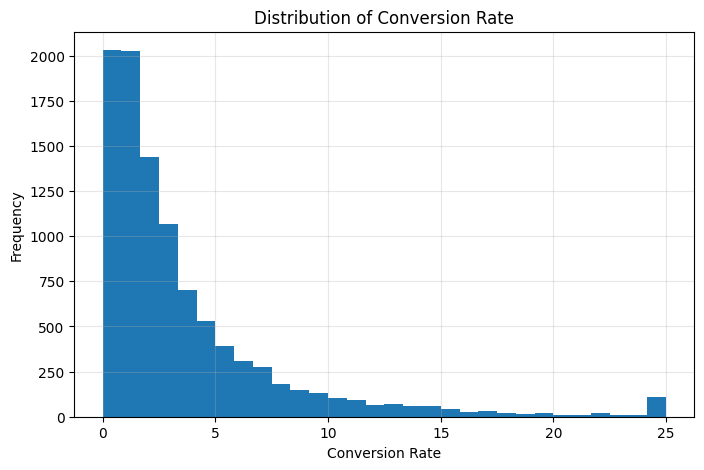

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["conversion_rate"], bins=30)
plt.title("Distribution of Conversion Rate")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

## Campaign Performance

### Business Question

Which campaign objectives perform the best?

In [15]:
campaign = df.groupby("campaign_objective")[["revenue","profit","conversions"]].mean()

campaign.sort_values("profit", ascending=False)

,revenue,profit,conversions
campaign_objective,,,
Conversions,34103.622288,29844.680713,80.060760
Lead Generation,30857.174064,26542.979604,72.192254
App Installs,23346.226314,19860.488418,49.552279
Engagement,23139.991553,18820.964288,51.411681
Brand Awareness,19620.051454,14771.775663,43.833089


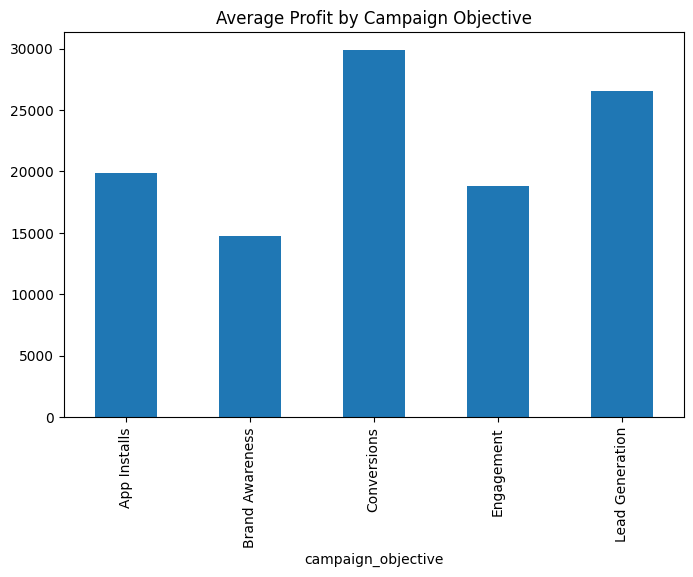

In [16]:
campaign["profit"].plot(kind="bar", figsize=(8,5))
plt.title("Average Profit by Campaign Objective")
plt.show()

## Platform Analysis

### Business Question

Which advertising platform generates the highest revenue?

Group by:
- Platform
- Revenue
- Profit
- ROAS
- CTR

#### Q1. Which platform generates the highest revenue?

platform
Google Ads    97848798.52
Facebook      70786373.13
TikTok        34349996.88
LinkedIn      33315694.35
Instagram     27041357.50
Twitter       20815486.09
Name: revenue, dtype: float64


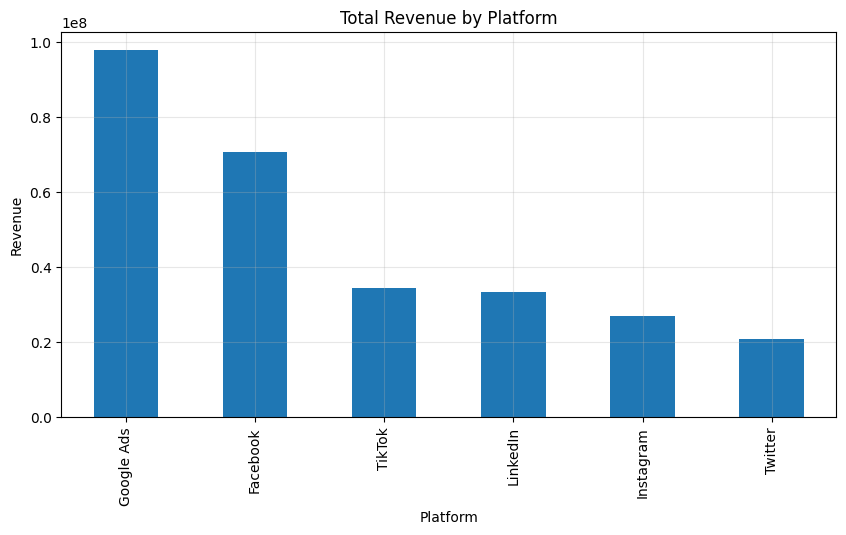

In [19]:
platform_revenue = df.groupby("platform")["revenue"].sum().sort_values(ascending=False)

print(platform_revenue)

plt.figure(figsize=(10,5))
platform_revenue.plot(kind="bar")
plt.title("Total Revenue by Platform")
plt.xlabel("Platform")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

#### Q2. Which platform generates the highest profit?

platform
Google Ads    79841954.44
Facebook      63970995.68
TikTok        31278715.96
Instagram     24074175.29
LinkedIn      23234821.74
Twitter       18301381.57
Name: profit, dtype: float64


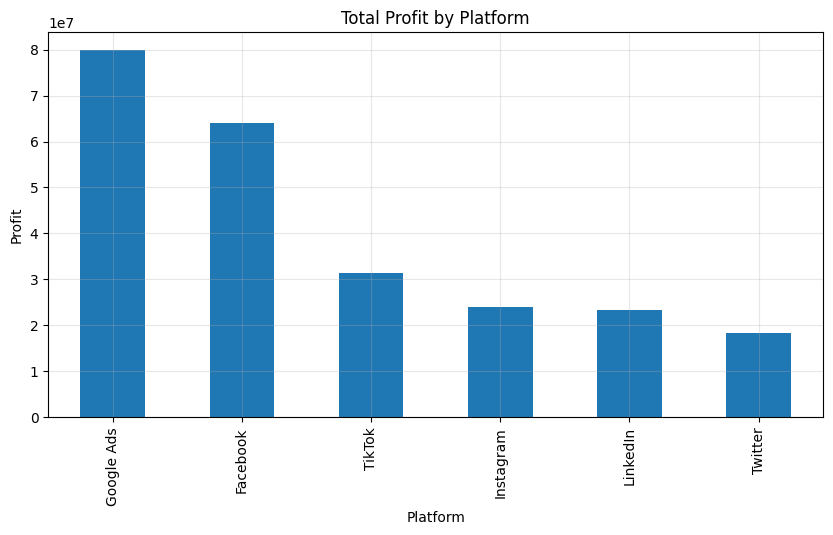

In [20]:
platform_profit = df.groupby("platform")["profit"].sum().sort_values(ascending=False)

print(platform_profit)

plt.figure(figsize=(10,5))
platform_profit.plot(kind="bar")
plt.title("Total Profit by Platform")
plt.xlabel("Platform")
plt.ylabel("Profit")
plt.grid(alpha=0.3)
plt.show()

#### Q3. Which platform has the highest CTR?

platform
TikTok        2.448493
Twitter       2.421934
Facebook      2.421710
Instagram     2.376488
LinkedIn      2.187046
Google Ads    2.174729
Name: CTR, dtype: float64


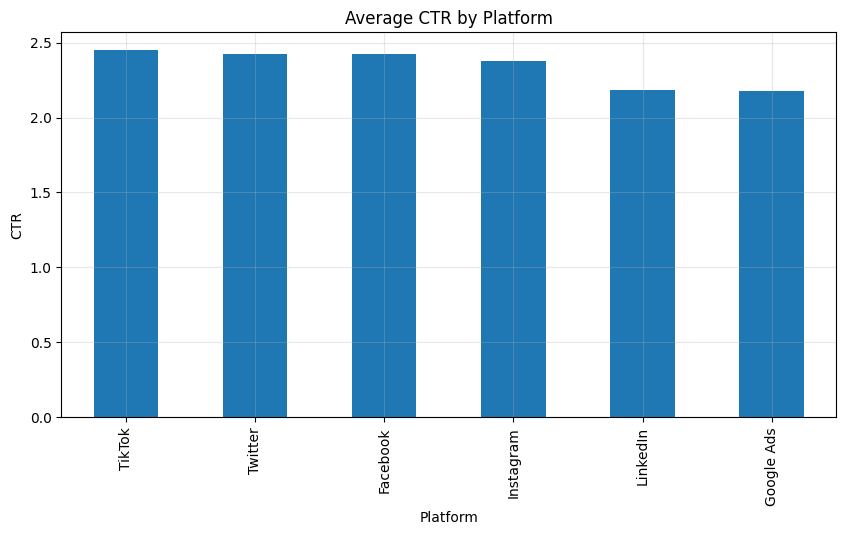

In [21]:
platform_ctr = df.groupby("platform")["CTR"].mean().sort_values(ascending=False)

print(platform_ctr)

plt.figure(figsize=(10,5))
platform_ctr.plot(kind="bar")
plt.title("Average CTR by Platform")
plt.xlabel("Platform")
plt.ylabel("CTR")
plt.grid(alpha=0.3)
plt.show()

#### Q4.Which platform has the highest ROAS?

platform
TikTok        10.848689
Facebook      10.005018
Instagram      8.376819
Twitter        8.233100
Google Ads     5.764293
LinkedIn       3.048876
Name: ROAS, dtype: float64


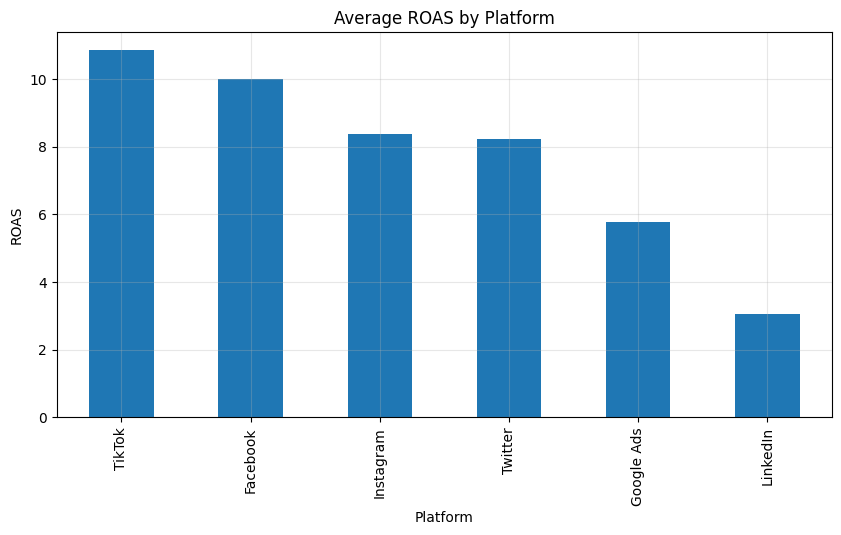

In [22]:
platform_roas = df.groupby("platform")["ROAS"].mean().sort_values(ascending=False)

print(platform_roas)

plt.figure(figsize=(10,5))
platform_roas.plot(kind="bar")
plt.title("Average ROAS by Platform")
plt.xlabel("Platform")
plt.ylabel("ROAS")
plt.grid(alpha=0.3)
plt.show()

#### Q5.Which campaign objective generates the highest conversions?

campaign_objective
Lead Generation    257221
Conversions        235859
Brand Awareness     89551
App Installs        36966
Engagement          36091
Name: conversions, dtype: int64


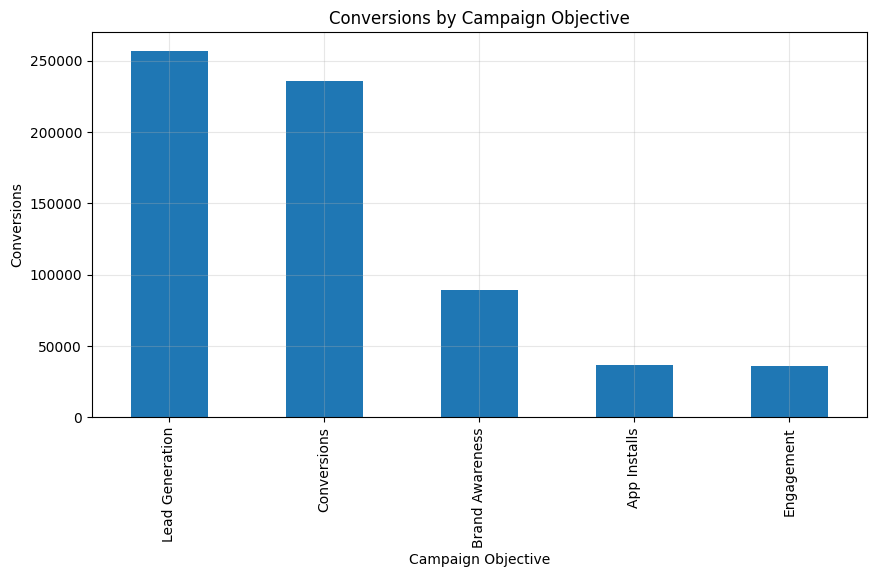

In [23]:
campaign = df.groupby("campaign_objective")["conversions"].sum().sort_values(ascending=False)

print(campaign)

plt.figure(figsize=(10,5))
campaign.plot(kind="bar")
plt.title("Conversions by Campaign Objective")
plt.xlabel("Campaign Objective")
plt.ylabel("Conversions")
plt.grid(alpha=0.3)
plt.show()

## Device Analysis

### Business Question

Which device converts the most?

Group by:
- Device
- Revenue
- Profit
- Conversion Rate

#### Revenue by Device

device_type
Desktop    1.769896e+08
Mobile     8.685688e+07
Tablet     2.031126e+07
Name: revenue, dtype: float64


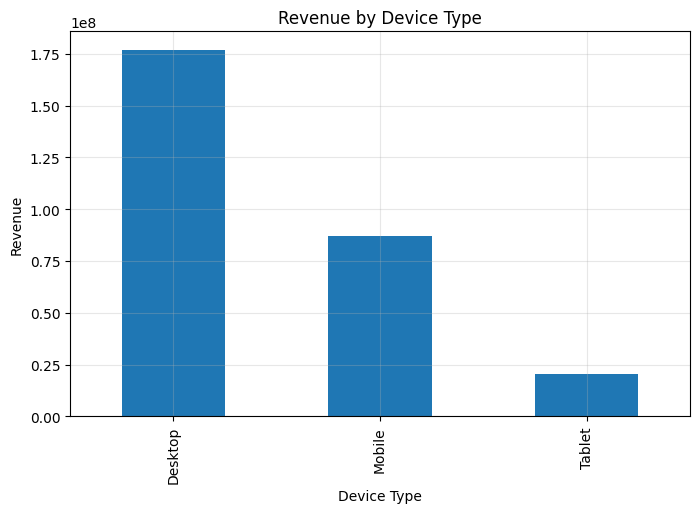

In [24]:
device_revenue = df.groupby("device_type")["revenue"].sum().sort_values(ascending=False)

print(device_revenue)

plt.figure(figsize=(8,5))
device_revenue.plot(kind="bar")
plt.title("Revenue by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

#### Profit by Device

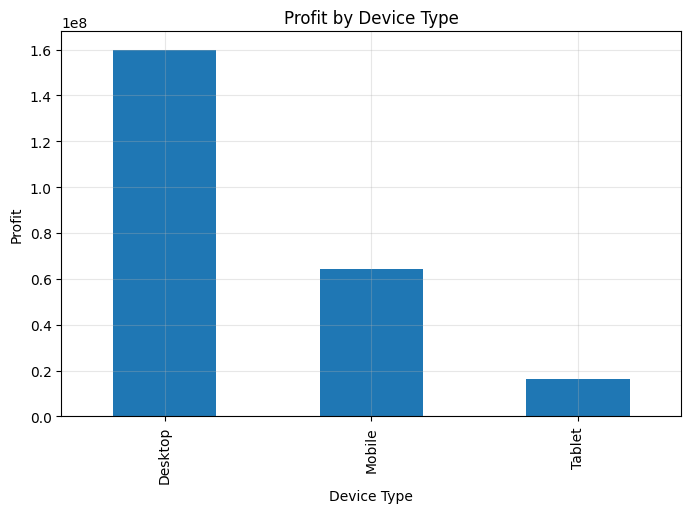

In [25]:
device_profit = df.groupby("device_type")["profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
device_profit.plot(kind="bar")
plt.title("Profit by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Profit")
plt.grid(alpha=0.3)
plt.show()

#### Conversion Rate by Device

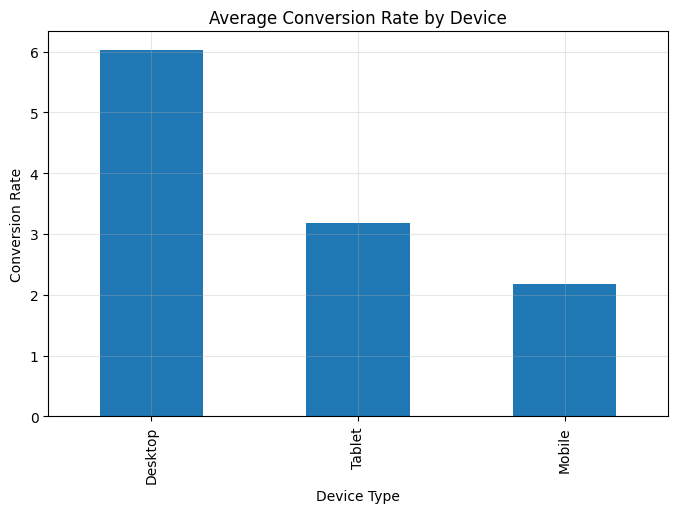

In [26]:
device_conversion = df.groupby("device_type")["conversion_rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
device_conversion.plot(kind="bar")
plt.title("Average Conversion Rate by Device")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate")
plt.grid(alpha=0.3)
plt.show()

## Audience Analysis

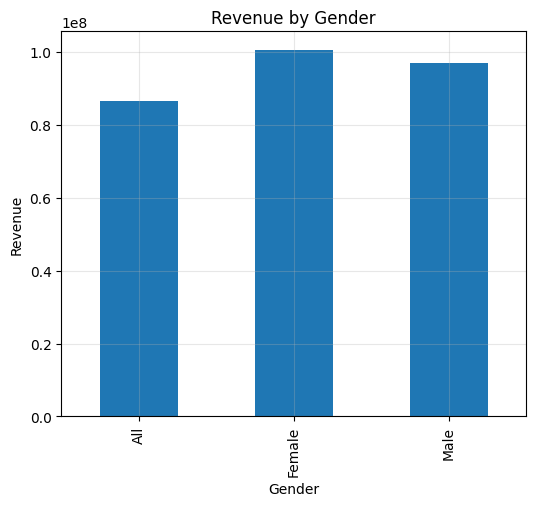

In [27]:
gender = df.groupby("target_audience_gender")["revenue"].sum()

plt.figure(figsize=(6,5))
gender.plot(kind="bar")
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

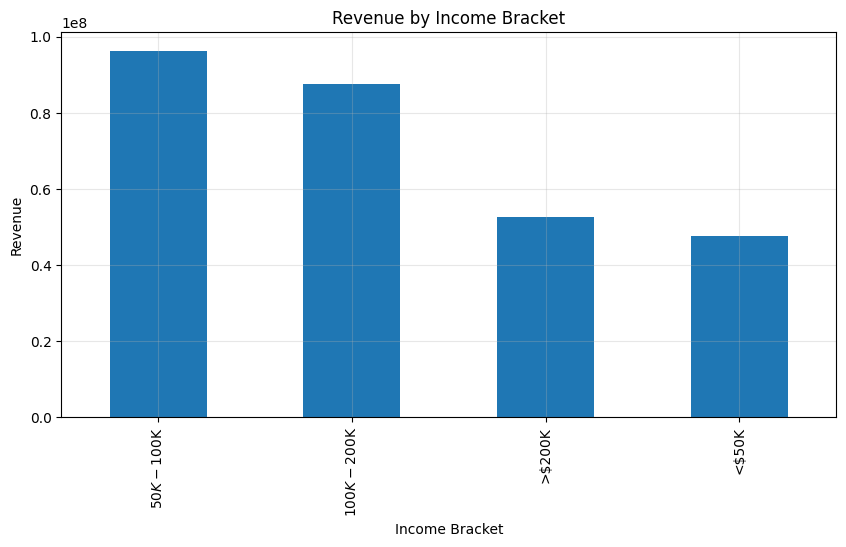

In [28]:
income = df.groupby("income_bracket")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
income.plot(kind="bar")
plt.title("Revenue by Income Bracket")
plt.xlabel("Income Bracket")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

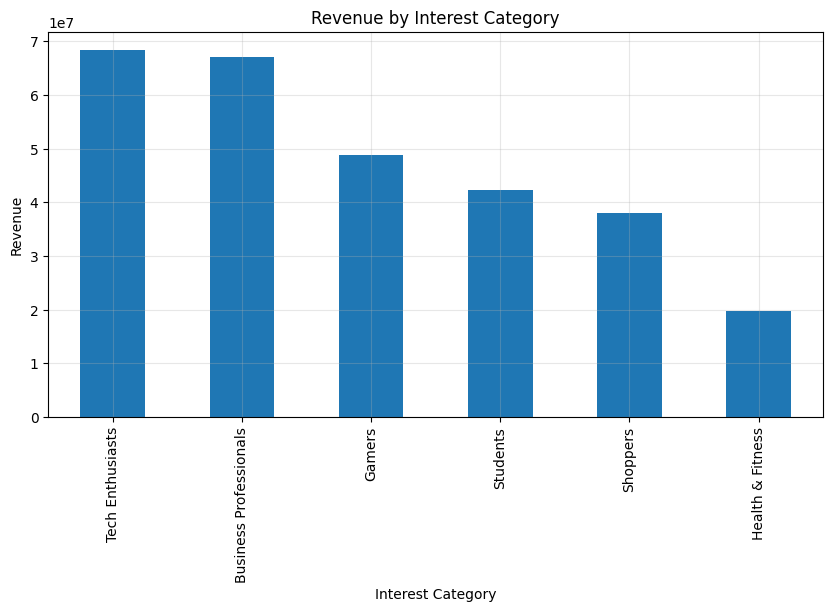

In [29]:
interest = df.groupby("audience_interest_category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
interest.plot(kind="bar")
plt.title("Revenue by Interest Category")
plt.xlabel("Interest Category")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

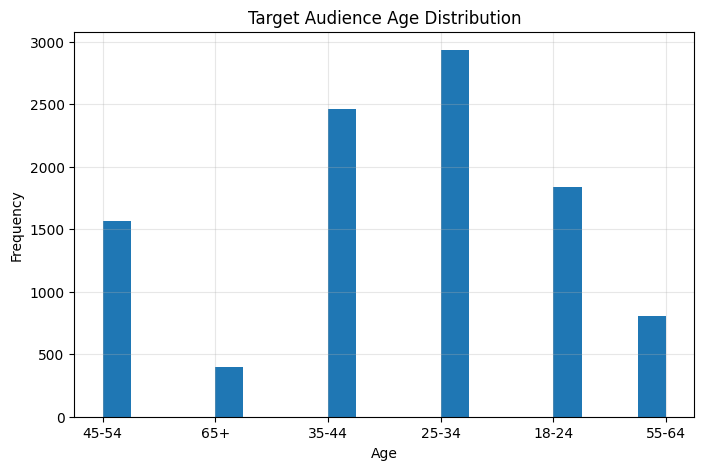

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df["target_audience_age"], bins=20)
plt.title("Target Audience Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

## Time Analysis

## Business Questions

- Best Month
- Best Quarter
- Best Weekday

#### Revenue by Month

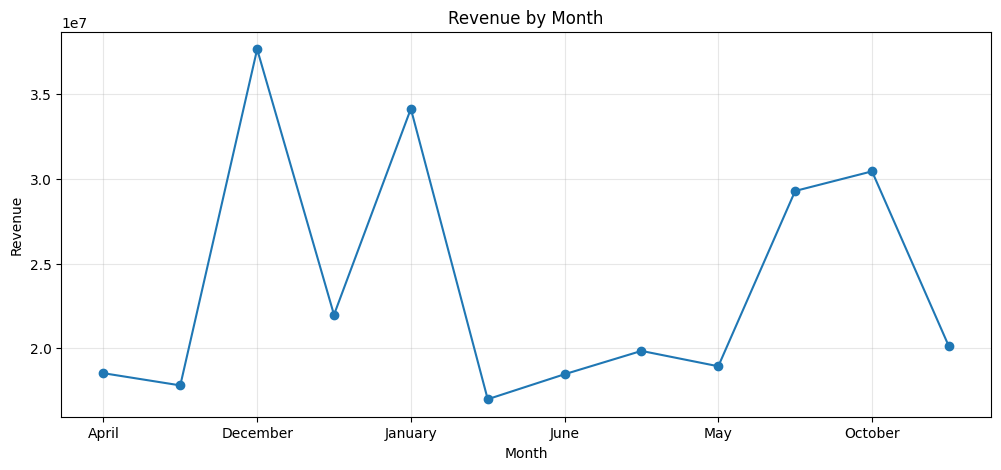

In [31]:
month = df.groupby("Month")["revenue"].sum()

plt.figure(figsize=(12,5))
month.plot(kind="line", marker="o")
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

#### Profit by Quarter

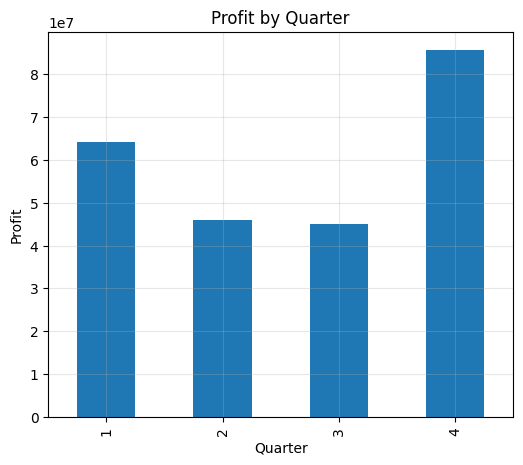

In [32]:
quarter = df.groupby("Quarter")["profit"].sum()

plt.figure(figsize=(6,5))
quarter.plot(kind="bar")
plt.title("Profit by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Profit")
plt.grid(alpha=0.3)
plt.show()

#### Revenue by Weekday

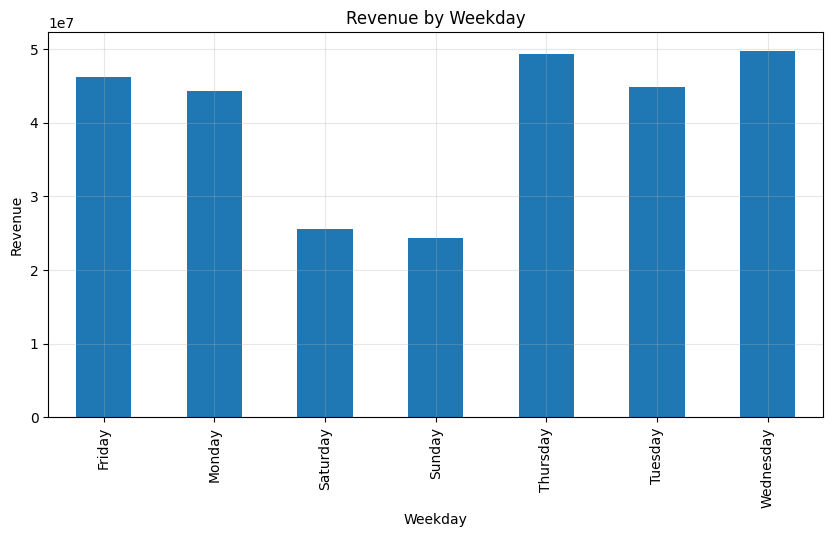

In [33]:
weekday = df.groupby("Weekday")["revenue"].sum()

plt.figure(figsize=(10,5))
weekday.plot(kind="bar")
plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

## Financial Analysis

### Business Questions

- Highest ROAS
- Highest Profit
- Highest Revenue
- Lowest CPA

## Top 10 Campaigns

In [36]:
top_revenue = df.nlargest(10,"revenue")

top_revenue[["campaign_id","platform","revenue","profit"]]

,campaign_id,platform,revenue,profit
590,CAMP_00591,TikTok,2800397.43,2750397.93
3997,CAMP_03998,Facebook,2231447.67,2193628.49
8878,CAMP_08879,Google Ads,2089944.93,2039950.92
5003,CAMP_05004,Google Ads,1990489.74,1942156.70
7528,CAMP_07529,Twitter,1822157.70,1774660.18
6646,CAMP_06647,Instagram,1750031.40,1735060.95
8552,CAMP_08553,Facebook,1389697.14,1360105.38
4030,CAMP_04031,Facebook,1263292.71,1232461.64
3870,CAMP_03871,TikTok,1258308.08,1238309.20
6843,CAMP_06844,TikTok,1234132.79,1184134.81


In [37]:
top_profit = df.nlargest(10,"profit")

top_profit[["campaign_id","platform","profit"]]

,campaign_id,platform,profit
590,CAMP_00591,TikTok,2750397.93
3997,CAMP_03998,Facebook,2193628.49
8878,CAMP_08879,Google Ads,2039950.92
5003,CAMP_05004,Google Ads,1942156.70
7528,CAMP_07529,Twitter,1774660.18
6646,CAMP_06647,Instagram,1735060.95
8552,CAMP_08553,Facebook,1360105.38
3870,CAMP_03871,TikTok,1238309.20
4030,CAMP_04031,Facebook,1232461.64
6843,CAMP_06844,TikTok,1184134.81


#### Revenue vs Ad Spend

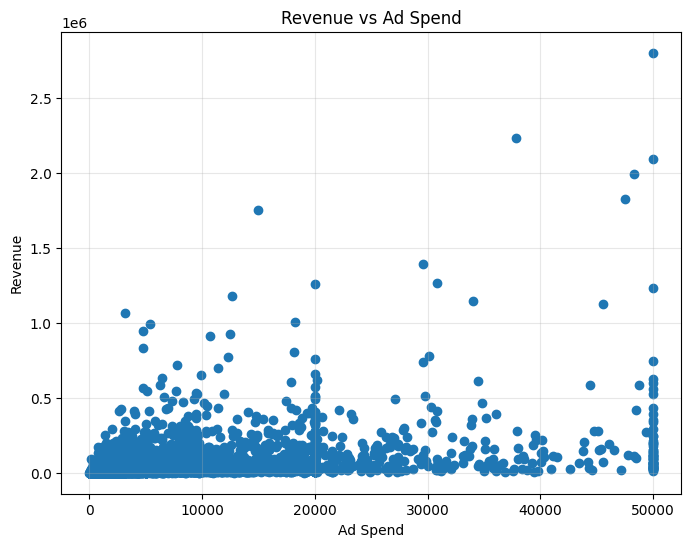

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(df["ad_spend"],df["revenue"])
plt.title("Revenue vs Ad Spend")
plt.xlabel("Ad Spend")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

#### Profit Distribution

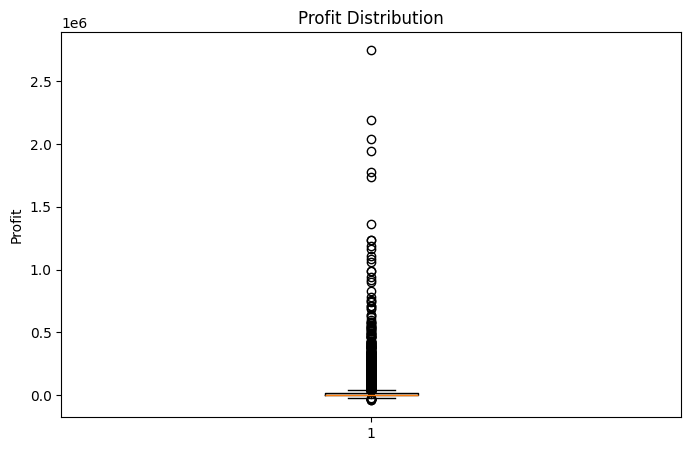

In [39]:
plt.figure(figsize=(8,5))
plt.boxplot(df["profit"])
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.show()

## Bottom 10 Campaigns

In [35]:
df.nsmallest(10, "profit")

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit,Year,Month,Quarter,Weekday
2554,CAMP_02555,Brand Awareness,LinkedIn,Display Network,Desktop,macOS,Image,1080x1080,Short,True,Neutral,36,25-34,Female,Business Professionals,$50K-$100K,Medium,False,2024-04-08,2,Monday,20,3,7,11.18,259554,4472,60,49996.96,13057.12,45.82,134,1.56,Education,High,1.723,11.18,1.342,833.28,0.26,-36939.84,2024,April,2,Monday
9031,CAMP_09032,Conversions,LinkedIn,Feed,Mobile,Android,Carousel,300x250,Long,False,Neutral,30,18-24,Female,Health & Fitness,<$50K,Low,False,2024-07-20,3,Saturday,11,54,7,7.80,156001,5060,35,39468.00,3590.75,66.49,90,2.93,Gaming,High,3.244,7.80,0.692,1127.66,0.09,-35877.25,2024,July,3,Saturday
3266,CAMP_03267,Lead Generation,Google Ads,Feed,Mobile,Windows,Story,1920x1080,Short,True,Urgency,12,35-44,Female,Health & Fitness,$100K-$200K,Low,False,2024-03-27,1,Wednesday,4,5,5,6.62,365687,5573,23,36893.26,3589.69,67.32,66,3.56,E-commerce,High,1.524,6.62,0.413,1604.05,0.10,-33303.57,2024,March,1,Wednesday
6606,CAMP_06607,Brand Awareness,LinkedIn,Search,Mobile,Android,Image,728x90,Medium,True,Fear,44,25-34,Male,Tech Enthusiasts,$50K-$100K,Low,False,2024-05-10,2,Friday,7,67,7,7.67,197002,6518,33,49993.06,16766.16,72.87,109,3.48,SaaS,High,3.309,7.67,0.506,1514.94,0.34,-33226.90,2024,May,2,Friday
5954,CAMP_05955,Brand Awareness,Google Ads,Feed,Mobile,iOS,Image,1200x628,Medium,False,Urgency,1,35-44,Male,Students,<$50K,Medium,False,2025-08-19,3,Tuesday,12,87,6,2.92,500000,16135,104,47114.20,17722.24,77.04,47,2.95,Education,High,3.227,2.92,0.645,453.02,0.38,-29391.96,2025,August,3,Tuesday
82,CAMP_00083,Lead Generation,LinkedIn,Feed,Mobile,Windows,Interactive,728x90,Medium,True,Urgency,56,25-34,Female,Students,<$50K,Low,False,2025-09-21,3,Sunday,6,9,6,6.92,161089,5433,54,37596.36,8508.89,80.25,69,2.61,E-commerce,High,3.373,6.92,0.994,696.23,0.23,-29087.47,2025,September,3,Sunday
6310,CAMP_06311,Lead Generation,LinkedIn,Feed,Mobile,Other,Image,728x90,Long,True,Neutral,9,18-24,Male,Tech Enthusiasts,<$50K,Medium,False,2024-06-23,2,Sunday,3,12,5,11.34,399853,4409,76,49998.06,22549.20,36.33,156,2.10,Healthcare,High,1.103,11.34,1.724,657.87,0.45,-27448.86,2024,June,2,Sunday
7310,CAMP_07311,Engagement,LinkedIn,Search,Tablet,iOS,Video,1920x1080,Short,True,Curiosity,42,25-34,Male,Tech Enthusiasts,<$50K,Low,False,2024-08-10,3,Saturday,14,43,6,8.71,336270,4573,25,39830.83,12394.71,66.46,30,2.46,Finance,High,1.360,8.71,0.547,1593.23,0.31,-27436.12,2024,August,3,Saturday
4838,CAMP_04839,Brand Awareness,Google Ads,Search,Mobile,iOS,Image,300x250,Short,True,Fear,37,18-24,Female,Students,$50K-$100K,Medium,False,2024-01-08,1,Monday,2,53,6,3.75,500000,9615,78,36056.25,11467.54,57.06,103,2.01,E-commerce,High,1.923,3.75,0.811,462.26,0.32,-24588.71,2024,January,1,Monday
7298,CAMP_07299,Lead Generation,LinkedIn,Display Network,Mobile,iOS,Video,728x90,Medium,True,Joy,55,25-34,Female,Business Professionals,$50K-$100K,Low,False,2025-05-04,2,Sunday,12,87,7,7.33,149302,6086,81,44610.38,20572.75,72.36,31,1.93,E-commerce,High,4.076,7.33,1.331,550.75,0.46,-24037.63,2025,May,2,Sunday


## Correlation Analysis

#### Correlation Matrix

In [40]:
corr = df.select_dtypes(include="number").corr()

corr

,creative_age_days,quarter,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,CTR,CPC,conversion_rate,CPA,ROAS,profit,Year,Quarter
creative_age_days,1.000000,-0.009228,0.001358,0.002478,-0.372632,0.060631,0.010268,-0.135043,-0.065796,-0.103477,-0.058727,-0.001274,-0.006284,-0.012174,-0.345060,0.060631,0.004573,0.004563,-0.023104,-0.052393,0.008474,-0.009228
quarter,-0.009228,1.000000,-0.018411,0.020396,0.001630,-0.009125,0.007568,0.070256,0.087740,0.044240,0.053997,0.010525,-0.014496,0.004191,0.151051,-0.009125,0.089760,-0.027326,0.026128,0.052248,-0.138118,1.000000
hour_of_day,0.001358,-0.018411,1.000000,0.014405,-0.000517,0.003713,-0.007448,-0.008407,-0.004776,0.002194,-0.005573,0.008045,-0.011328,0.006287,-0.004067,0.003713,0.001117,0.003374,-0.003911,-0.005934,0.015949,-0.018411
campaign_day,0.002478,0.020396,0.014405,1.000000,0.007894,-0.004937,0.012672,0.007506,-0.021806,0.006063,-0.010749,-0.002283,-0.012277,-0.002797,0.002741,-0.004937,-0.063657,0.013531,-0.033233,-0.011591,0.007343,0.020396
quality_score,-0.372632,0.001630,-0.000517,0.007894,1.000000,-0.143502,-0.007961,0.186136,0.126281,0.116903,0.112127,0.006244,-0.002638,0.002390,0.445793,-0.143502,0.080473,-0.080092,0.117246,0.106491,0.009086,0.001630
actual_cpc,0.060631,-0.009125,0.003713,-0.004937,-0.143502,1.000000,-0.037471,-0.114374,-0.036291,0.291029,-0.028349,-0.014155,0.010354,0.014758,-0.133977,1.000000,0.106129,0.387349,-0.236948,-0.052586,0.008920,-0.009125
impressions,0.010268,0.007568,-0.007448,0.012672,-0.007961,-0.037471,1.000000,0.742296,0.371245,0.655696,0.332200,0.004441,-0.004001,-0.006073,-0.073822,-0.037471,-0.020677,0.060267,-0.009507,0.290740,-0.015963,0.007568
clicks,-0.135043,0.070256,-0.008407,0.007506,0.186136,-0.114374,0.742296,1.000000,0.641880,0.729816,0.551034,-0.026249,0.016095,0.012113,0.345435,-0.114374,0.094693,-0.070204,0.100645,0.510905,-0.019361,0.070256
conversions,-0.065796,0.087740,-0.004776,-0.021806,0.126281,-0.036291,0.371245,0.641880,1.000000,0.497338,0.842255,-0.238646,0.155175,0.196435,0.331556,-0.036291,0.469359,-0.151086,0.302439,0.830402,-0.006686,0.087740
ad_spend,-0.103477,0.044240,0.002194,0.006063,0.116903,0.291029,0.655696,0.729816,0.497338,1.000000,0.446753,-0.024175,0.015845,0.009273,0.216258,0.291029,0.136325,0.084268,-0.041337,0.381534,-0.012546,0.044240


#### Highest Correlations

In [41]:
corr["profit"].sort_values(ascending=False)

profit                          1.000000
revenue                         0.997432
conversions                     0.830402
clicks                          0.510905
ROAS                            0.432579
conversion_rate                 0.402843
ad_spend                        0.381534
impressions                     0.290740
CTR                             0.266422
pages_per_session               0.179107
avg_session_duration_seconds    0.141331
quality_score                   0.106491
Quarter                         0.052248
quarter                         0.052248
Year                           -0.002777
hour_of_day                    -0.005934
campaign_day                   -0.011591
creative_age_days              -0.052393
actual_cpc                     -0.052586
CPC                            -0.052586
CPA                            -0.144140
bounce_rate                    -0.221660
Name: profit, dtype: float64

#### Revenue Correlations

In [42]:
corr["revenue"].sort_values(ascending=False)

revenue                         1.000000
profit                          0.997432
conversions                     0.842255
clicks                          0.551034
ad_spend                        0.446753
ROAS                            0.415478
conversion_rate                 0.400463
impressions                     0.332200
CTR                             0.274617
pages_per_session               0.174071
avg_session_duration_seconds    0.138018
quality_score                   0.112127
quarter                         0.053997
Quarter                         0.053997
Year                           -0.003660
hour_of_day                    -0.005573
campaign_day                   -0.010749
actual_cpc                     -0.028349
CPC                            -0.028349
creative_age_days              -0.058727
CPA                            -0.132980
bounce_rate                    -0.216411
Name: revenue, dtype: float64

#### Conversion Correlations

In [43]:
corr["conversions"].sort_values(ascending=False)

conversions                     1.000000
revenue                         0.842255
profit                          0.830402
clicks                          0.641880
ad_spend                        0.497338
conversion_rate                 0.469359
impressions                     0.371245
CTR                             0.331556
ROAS                            0.302439
pages_per_session               0.196435
avg_session_duration_seconds    0.155175
quality_score                   0.126281
Quarter                         0.087740
quarter                         0.087740
hour_of_day                    -0.004776
Year                           -0.006686
campaign_day                   -0.021806
actual_cpc                     -0.036291
CPC                            -0.036291
creative_age_days              -0.065796
CPA                            -0.151086
bounce_rate                    -0.238646
Name: conversions, dtype: float64

## Business Insights

# Business Insights
## Executive Summary
The exploratory data analysis provided valuable insights into the performance of digital advertising campaigns across multiple platforms, audience segments, devices, and campaign objectives.
### Key Insights
- Campaign performance varies across advertising platforms, indicating that some platforms generate higher revenue, profit, and return on advertising spend (ROAS) than others.
- Customer demographics, including age group, gender, and income bracket, influence campaign performance and conversion rates.
- Device type plays an important role in user engagement and campaign success, highlighting opportunities for device-specific marketing strategies.
- Advertising spend has a positive relationship with campaign revenue; however, higher spending does not always result in higher profitability.
- Campaign objectives differ in effectiveness, suggesting that marketing goals significantly impact campaign outcomes.
- Revenue, profit, CTR, conversion rate, CPA, and ROAS are the primary performance indicators for evaluating campaign success.
- Time-based analysis helps identify high-performing months, quarters, and weekdays that can be used for better campaign scheduling and budget allocation.
### Business Recommendations
- Allocate a larger marketing budget to high-performing advertising platforms.
- Optimize or discontinue campaigns with consistently low ROAS or negative profit.
- Focus marketing efforts on audience segments with higher conversion rates and stronger purchase intent.
- Improve campaign creatives and landing pages to increase CTR and conversion rates.
- Prioritize device platforms that generate higher customer engagement and revenue.
- Continuously monitor campaign performance using business intelligence dashboards to support data-driven decision-making.
## Conclusion
The exploratory analysis establishes a strong foundation for advanced SQL analysis and Power BI dashboard development. The insights obtained from this notebook will be used to answer business questions, evaluate marketing performance, and support strategic marketing decisions.